# 1. Time Series Review
# Plot monthly mean discharge and concentration for two hydrological stations

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, probplot, pearsonr
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox


In [2]:
#Change root to your folder path
root = r'c:\Users\leoni\OneDrive\Documents\Master Umwelting ETH\Semester 2\Labor WRM\Asssignment 2\Assignment 2-20260512\DATA\DATA'
#root = r'C:\Users\Sylvie\OneDrive\ETH\Master\2_Semester\Lab_WRM\2_ex\DATA\DATA'
qD = pd.read_csv(os.path.join(root,'Q_Diepoldsau_m3s.csv'), parse_dates=['timestamp']).set_index('timestamp')
qG = pd.read_csv(os.path.join(root,'Q_Gisingen_1976-2023.csv'), parse_dates=['timestamp']).set_index('timestamp')
sscD = pd.read_csv(os.path.join(root,'SSC_Diepoldsau_gL.csv'), parse_dates=['timestamp']).set_index('timestamp')
sscG = pd.read_csv(os.path.join(root,'SSC_Gisingen_2003-2020.csv'), parse_dates=['timestamp']).set_index('timestamp')

In [3]:
display(qD.head(2))
display(qG.head(2))
display(sscD.head(2))
display(sscG.head(2))

,q_m3s
timestamp,
1984-01-01 00:00:00,113.081
1984-01-01 00:10:00,113.044


,q_m3s
timestamp,
1976-01-01 00:15:00,18.8
1976-01-01 00:30:00,18.7


,ssc_gL
timestamp,
2012-01-01 00:00:00,0.01785
2012-01-01 00:10:00,NaN


,ssc_gL
timestamp,
2004-01-01 00:00:00,0.0153
2004-01-01 00:15:00,0.0143


In [4]:
#monthly means
qD = qD.resample('ME').mean()
qG = qG.resample('ME').mean()
sscD = sscD.resample('ME').mean()
sscG = sscG.resample('ME').mean()

# Log-transform the monthly series to stabilise variance and improve stationarity
for df, name in [(qD, 'qD'), (qG, 'qG'), (sscD, 'sscD'), (sscG, 'sscG')]:
    if (df <= 0).any().any():
        raise ValueError(f'Non-positive values found in {name}; cannot take log.')

qD = np.log(qD)
qG = np.log(qG)
sscD = np.log(sscD)
sscG = np.log(sscG)

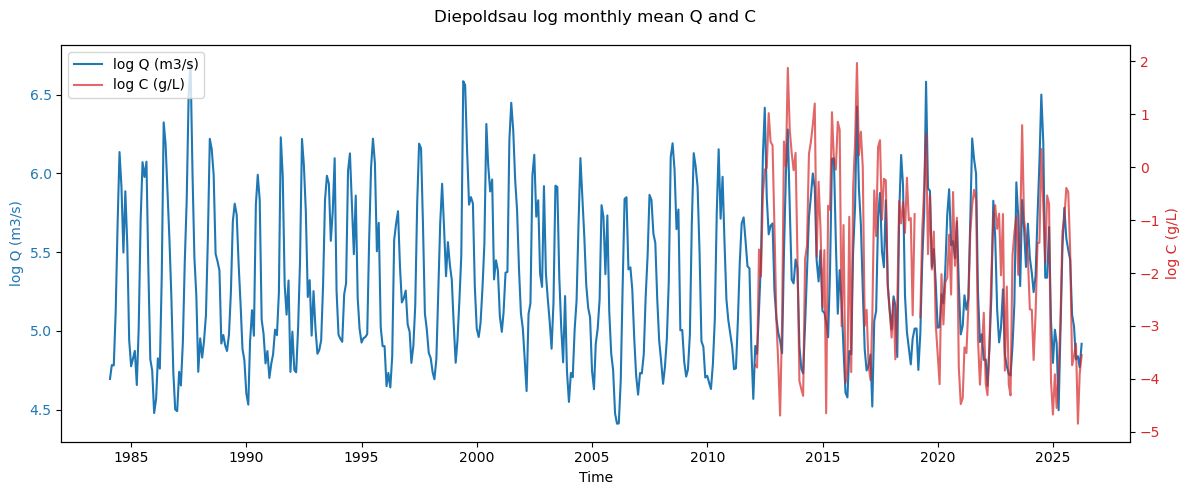

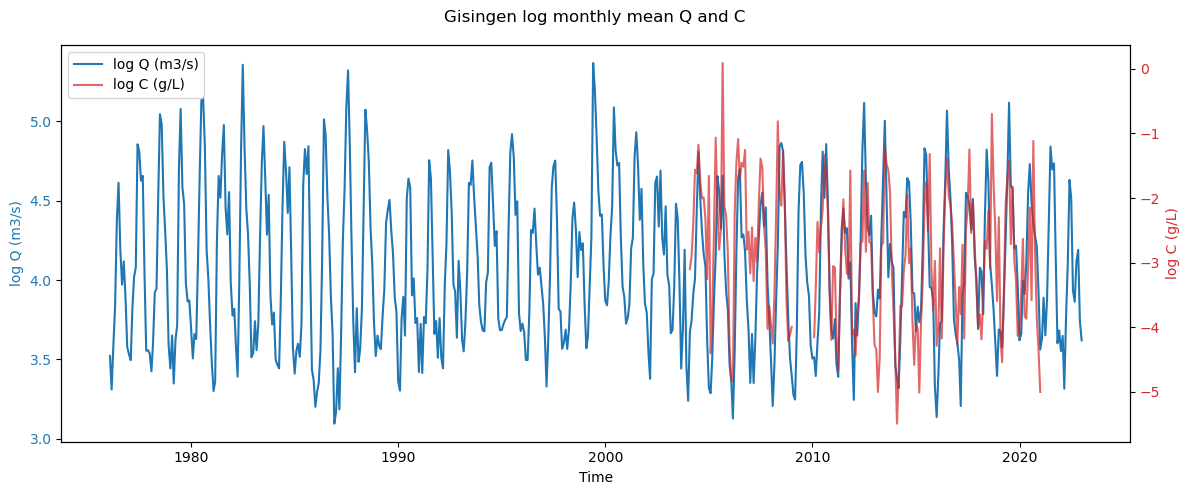

In [5]:
for station, dfQ, dfC in [('Diepoldsau', qD, sscD), ('Gisingen', qG, sscG)]:
    fig, ax = plt.subplots(figsize=(12,5))
    ax.plot(dfQ.index, dfQ['q_m3s'], label='log Q (m3/s)', color='tab:blue')
    ax.set_xlabel('Time')
    ax.set_ylabel('log Q (m3/s)', color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')
    ax2 = ax.twinx()
    ax2.plot(dfC.index, dfC.iloc[:,0], label='log C (g/L)', color='tab:red', alpha=0.7)
    ax2.set_ylabel('log C (g/L)', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc='upper left')
    fig.suptitle(f'{station} log monthly mean Q and C')
    fig.tight_layout()
    plt.show()

# 1.2 Stationarity test and trend removal
This section fits a linear trend to each station's log-transformed monthly mean discharge (Q) and concentration (C) series, tests the slope significance at the 5% level, removes any statistically significant trend, and verifies that the detrended series has zero mean and finite variance.

Diepoldsau Q: n=507, slope=0.000025, p=0.8660, significant=False
    detrend method = mean
    mean after detrending = -2.978113e-16
    variance after detrending = 2.332410e-01

Diepoldsau C: n=169, slope=-0.009834, p=0.0001, significant=True
    detrend method = linear trend
    mean after detrending = -5.255494e-17
    variance after detrending = 2.477745e+00

Gisingen Q: n=564, slope=0.000000, p=0.9972, significant=False
    detrend method = mean
    mean after detrending = -2.047220e-17
    variance after detrending = 2.326677e-01

Gisingen C: n=192, slope=-0.003792, p=0.0057, significant=True
    detrend method = linear trend
    mean after detrending = 7.308968e-16
    variance after detrending = 1.080631e+00



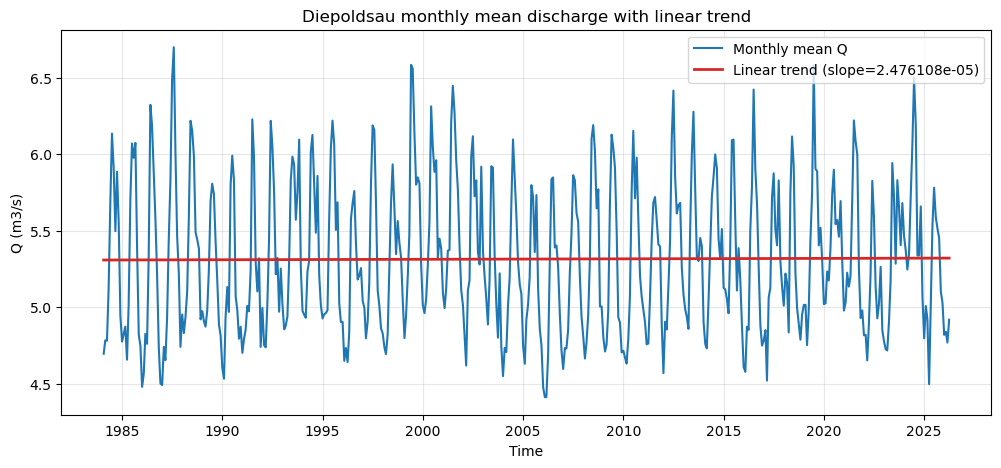

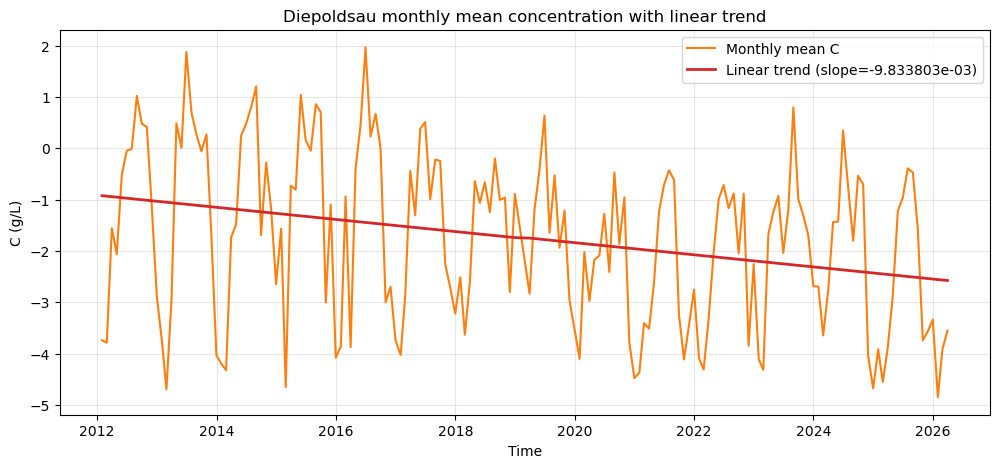

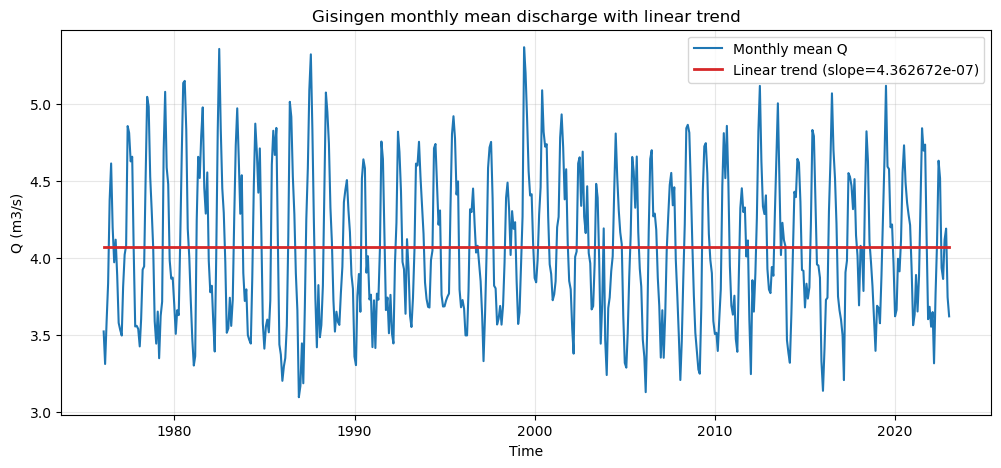

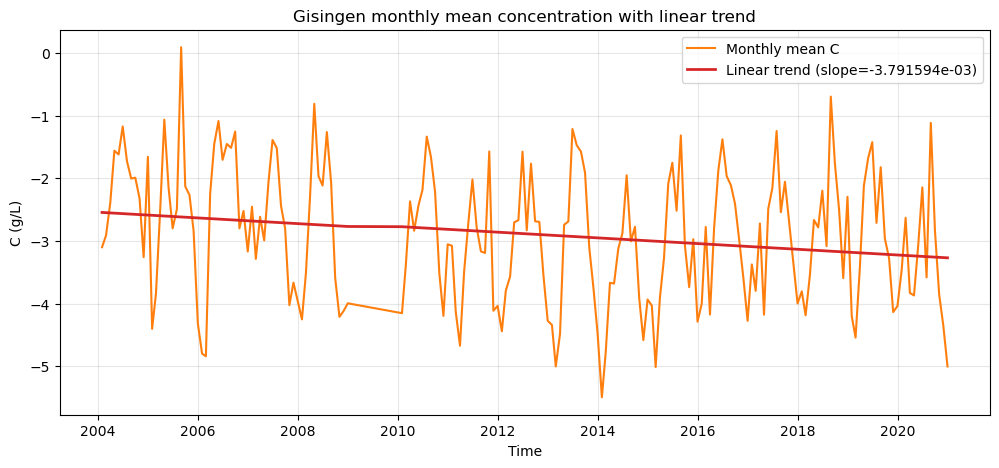

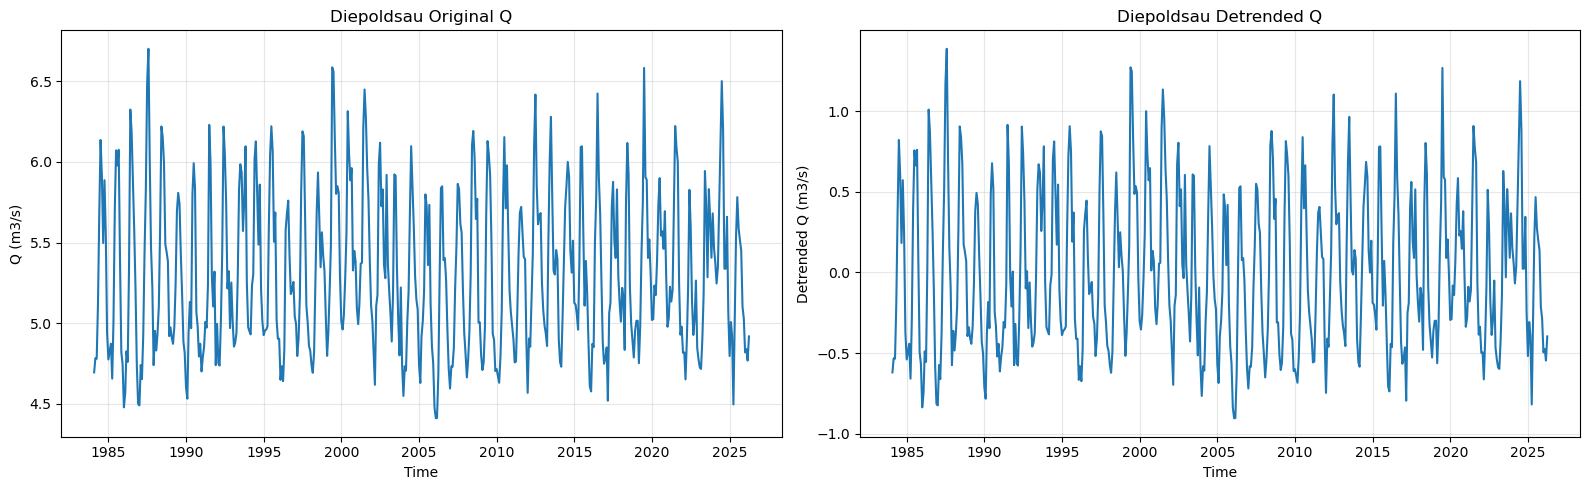

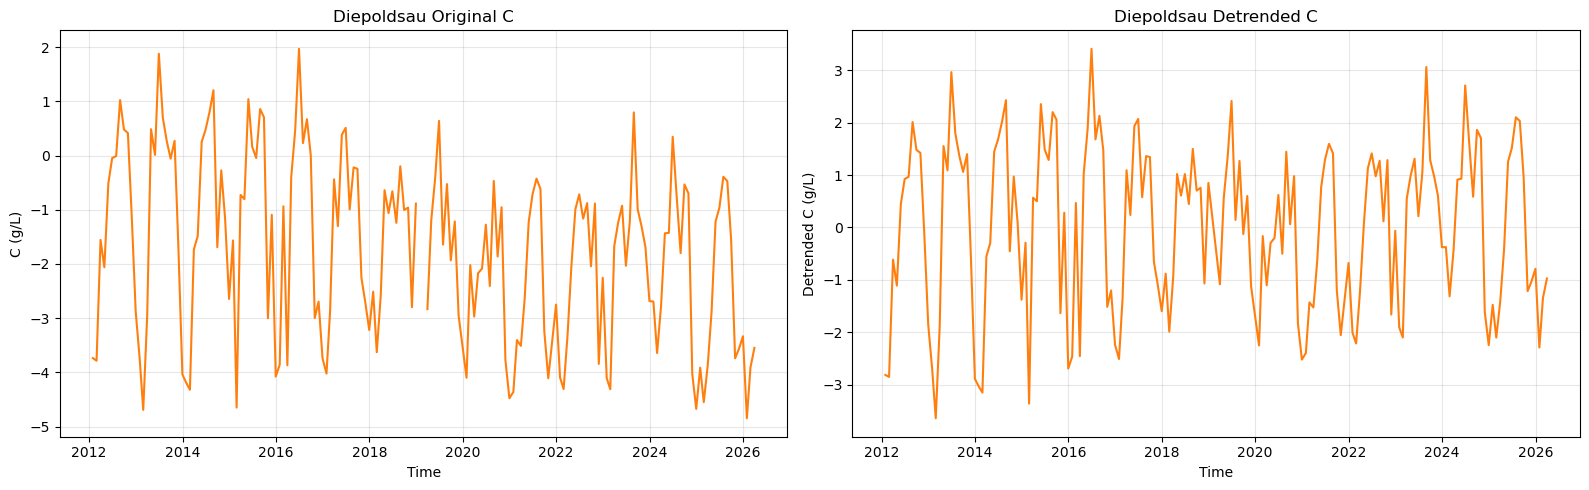

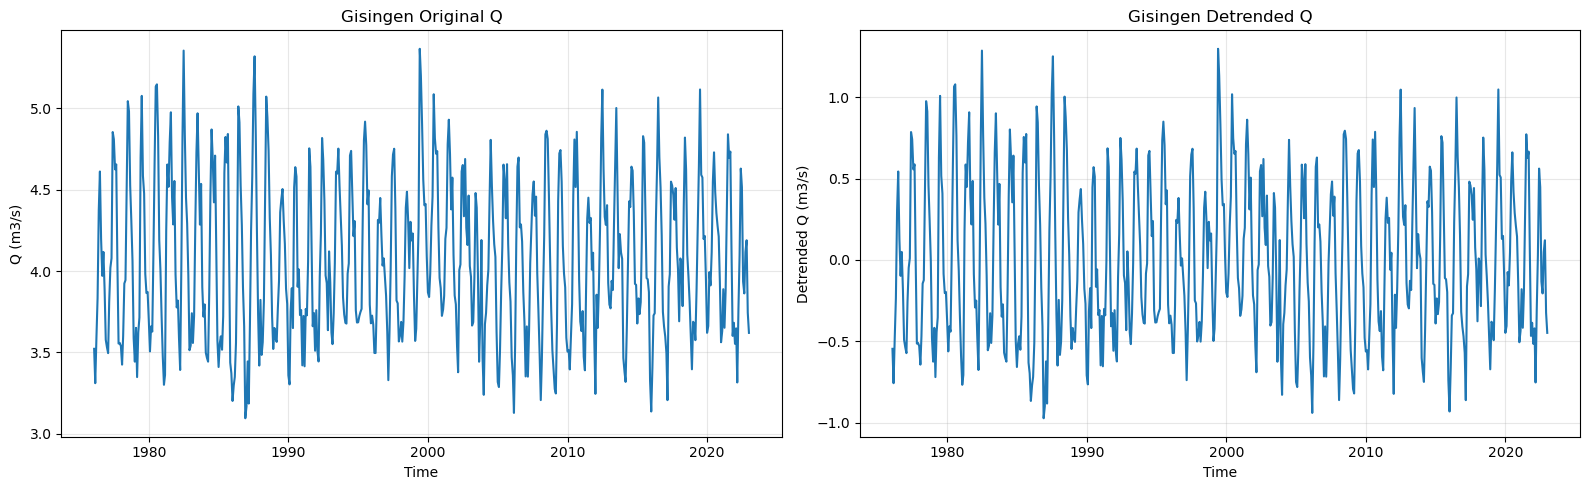

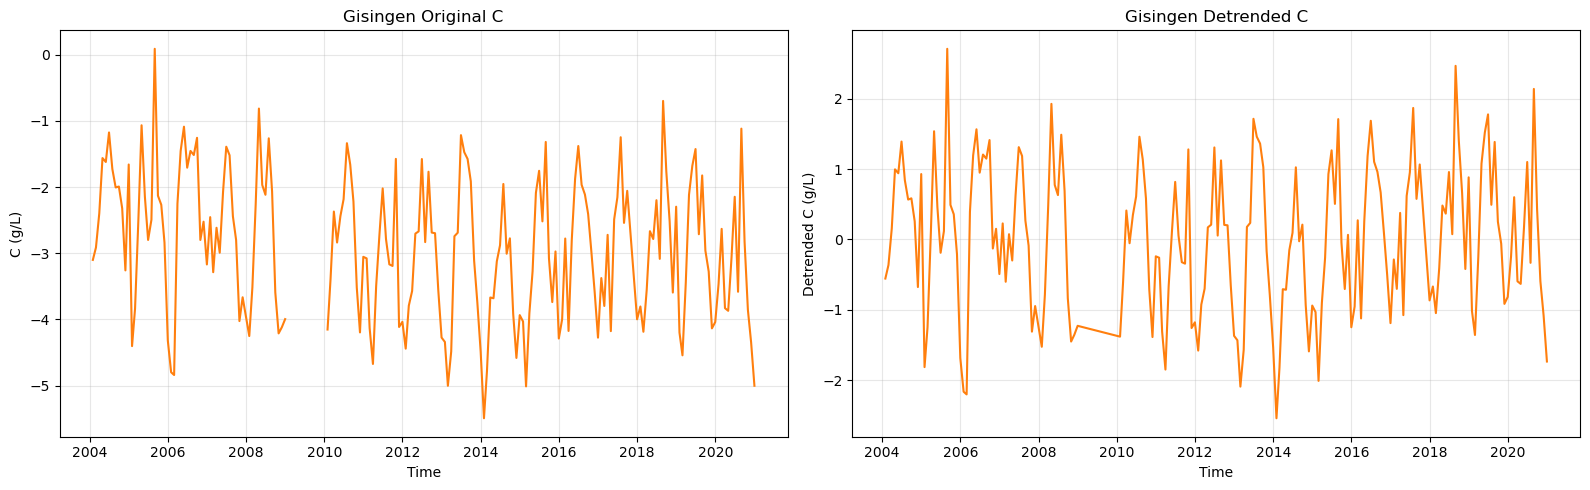

In [6]:
def test_and_detrend(df, column_name):

    y = df[column_name].dropna()
    x = np.arange(len(y))
    trend = linregress(x, y.values)
    pvalue = trend.pvalue
    significant = pvalue < 0.05
    if significant:
        detrended = y.values - (trend.intercept + trend.slope * x)
        detrend_method = 'linear trend'
    else:
        detrended = y.values - y.values.mean()
        detrend_method = 'mean'
    detrended_mean = detrended.mean()
    detrended_var = detrended.var(ddof=1)
    detrended_series = pd.Series(detrended, index=y.index)
    
    results = {
        'n_points': len(y),
        'slope': trend.slope,
        'pvalue': pvalue,
        'significant': significant,
        'detrend_method': detrend_method,
        'mean_after_detrend': detrended_mean,
        'variance_after_detrend': detrended_var,
    }
    return detrended_series, results

station_results = []
detrended_series = {}

for station, dfQ, dfC in [('Diepoldsau', qD, sscD), ('Gisingen', qG, sscG)]:
    # Detrend Q
    detrended_Q, results_Q = test_and_detrend(dfQ, 'q_m3s')
    detrended_series[f'Q_{station}'] = detrended_Q
    station_results.append({
        'station': station,
        'variable': 'Q',
        **results_Q
    })
    print(f"{station} Q: n={results_Q['n_points']}, slope={results_Q['slope']:.6f}, p={results_Q['pvalue']:.4f}, significant={results_Q['significant']}")
    print(f"    detrend method = {results_Q['detrend_method']}")
    print(f"    mean after detrending = {results_Q['mean_after_detrend']:.6e}")
    print(f"    variance after detrending = {results_Q['variance_after_detrend']:.6e}\n")
    
    # Detrend C (SSC)
    detrended_C, results_C = test_and_detrend(dfC, dfC.columns[0])
    detrended_series[f'C_{station}'] = detrended_C
    station_results.append({
        'station': station,
        'variable': 'C',
        **results_C
    })
    print(f"{station} C: n={results_C['n_points']}, slope={results_C['slope']:.6f}, p={results_C['pvalue']:.4f}, significant={results_C['significant']}")
    print(f"    detrend method = {results_C['detrend_method']}")
    print(f"    mean after detrending = {results_C['mean_after_detrend']:.6e}")
    print(f"    variance after detrending = {results_C['variance_after_detrend']:.6e}\n")

station_results_df = pd.DataFrame(station_results)
station_results_df

# Plot linear regression fit for each station and variable
for station, dfQ, dfC in [('Diepoldsau', qD, sscD), ('Gisingen', qG, sscG)]:
    # Plot for Q
    yQ = dfQ['q_m3s'].dropna()
    xQ = np.arange(len(yQ))
    trendQ = linregress(xQ, yQ.values)
    fittedQ = trendQ.intercept + trendQ.slope * xQ

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(yQ.index, yQ, label='Monthly mean Q', color='tab:blue')
    ax.plot(yQ.index, fittedQ, label=f'Linear trend (slope={trendQ.slope:.6e})', color='tab:red', linewidth=2)
    ax.set_title(f'{station} monthly mean discharge with linear trend')
    ax.set_xlabel('Time')
    ax.set_ylabel('Q (m3/s)')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    plt.show()
    
    # Plot for C
    yC = dfC.iloc[:,0].dropna()
    xC = np.arange(len(yC))
    trendC = linregress(xC, yC.values)
    fittedC = trendC.intercept + trendC.slope * xC

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(yC.index, yC, label='Monthly mean C', color='tab:orange')
    ax.plot(yC.index, fittedC, label=f'Linear trend (slope={trendC.slope:.6e})', color='tab:red', linewidth=2)
    ax.set_title(f'{station} monthly mean concentration with linear trend')
    ax.set_xlabel('Time')
    ax.set_ylabel('C (g/L)')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    plt.show()

# Plot original vs detrended series
for station in ['Diepoldsau', 'Gisingen']:
    for variable in ['Q', 'C']:
        if variable == 'Q':
            original = qD if station == 'Diepoldsau' else qG
            original_col = 'q_m3s'
            ylabel = 'Q (m3/s)'
            color = 'tab:blue'
        else:
            original = sscD if station == 'Diepoldsau' else sscG
            original_col = original.columns[0]
            ylabel = 'C (g/L)'
            color = 'tab:orange'
        detrended = detrended_series[f'{variable}_{station}']
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
        
        # Original
        ax1.plot(original.index, original[original_col], color=color)
        ax1.set_title(f'{station} Original {variable}')
        ax1.set_xlabel('Time')
        ax1.set_ylabel(ylabel)
        ax1.grid(True, alpha=0.3)
        
        # Detrended
        ax2.plot(detrended.index, detrended, color=color)
        ax2.set_title(f'{station} Detrended {variable}')
        ax2.set_xlabel('Time')
        ax2.set_ylabel(f'Detrended {ylabel}')
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# 2. Empirical Autocorrelation and Partial Autocorrelation Analysis
# Per professor's guidance: SSC data have gaps (Diepoldsau 2019, Gisingen 2009).
# We compute ACF/PACF separately before and after each gap, then average them.
# We also apply SEASONAL STANDARDISATION (Method 1) to remove the 12-month periodicity
# before computing ACF/PACF and fitting models.



=== Diepoldsau Q ===
  n after detrend+deseason: 507


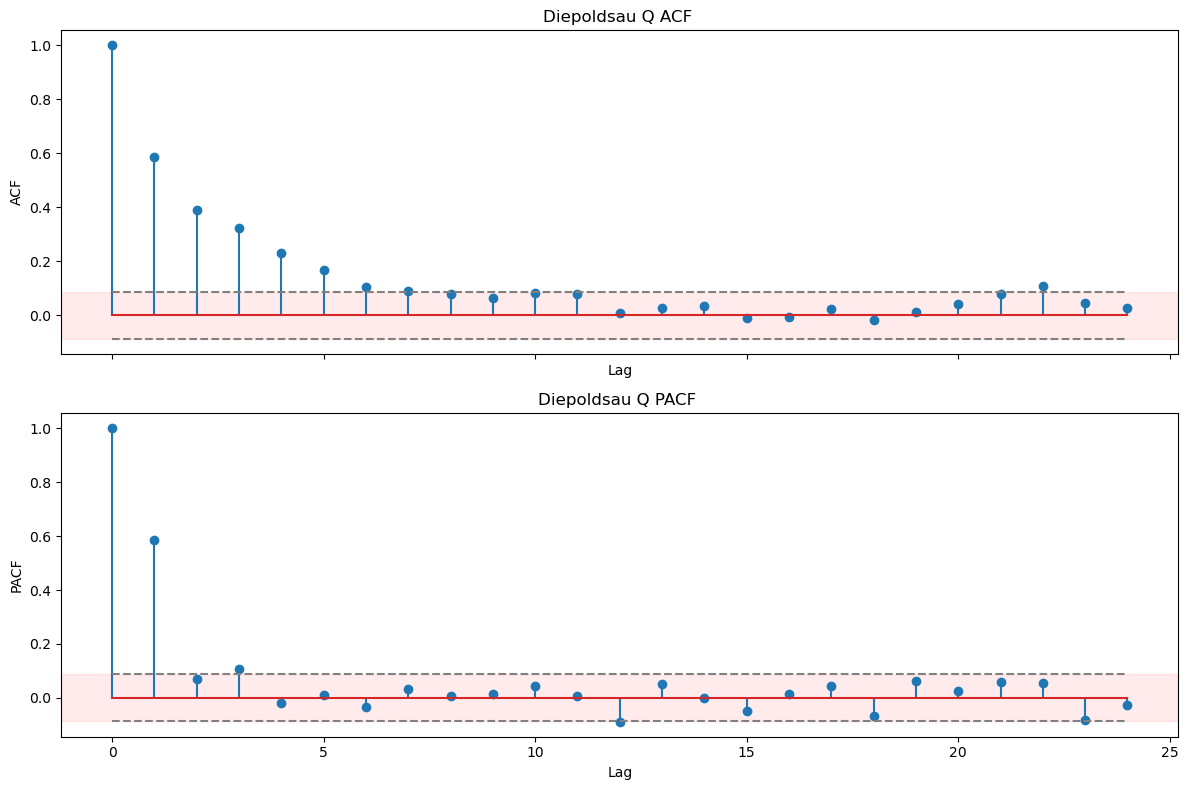


=== Diepoldsau C ===
  n after detrend+deseason: 169
  Gap detected at 2019-01-01 – splitting series.
  Segment "before gap": n=84
  Segment "after gap": n=85


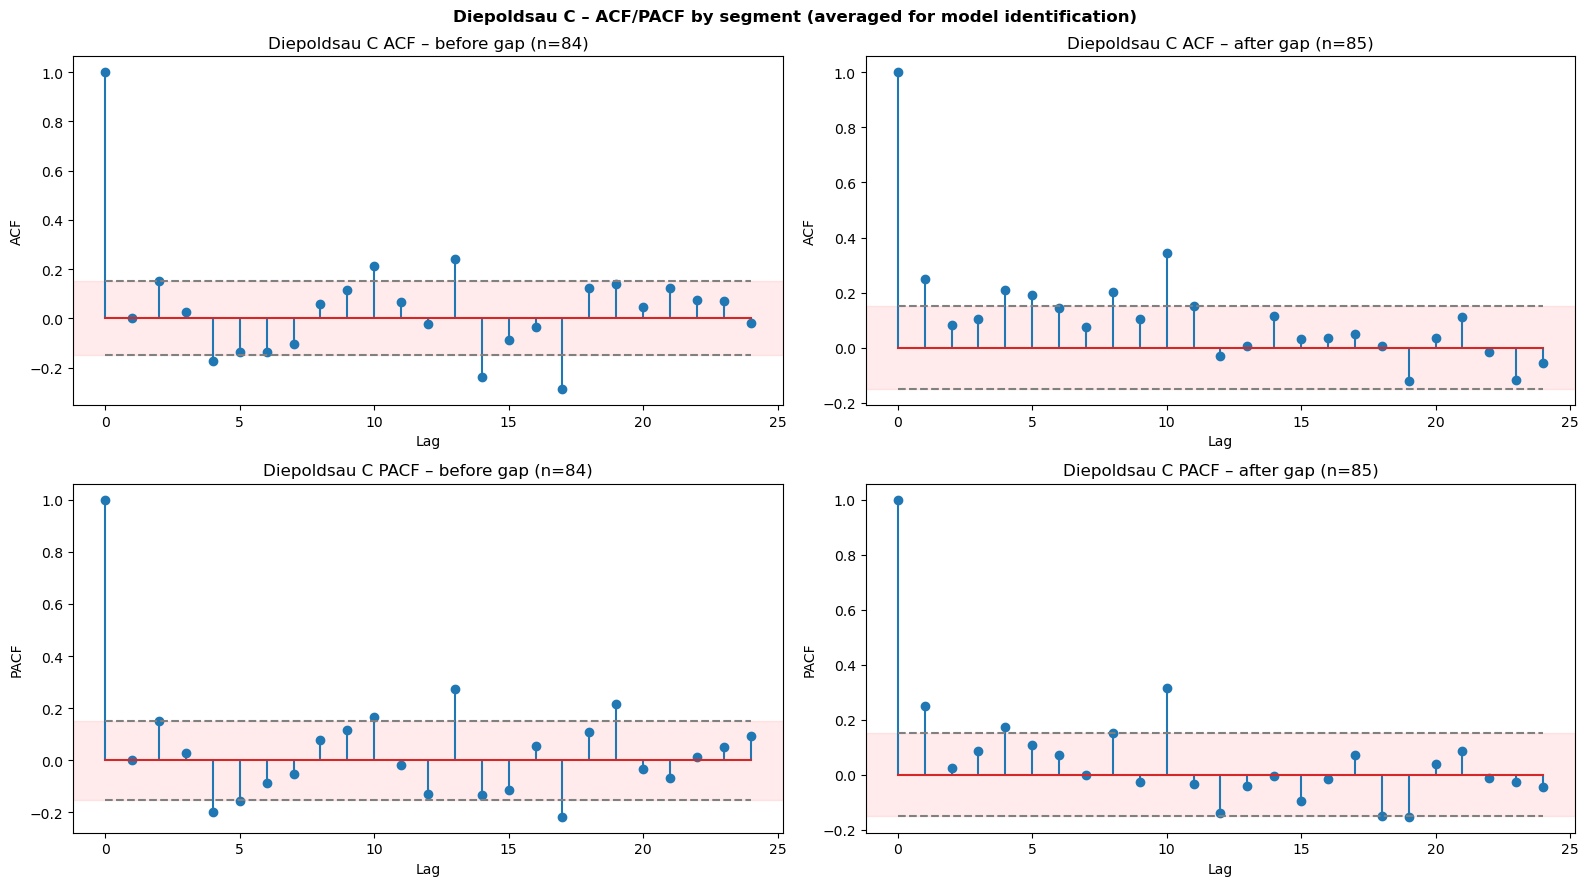

  Pearson r between segment ACFs: -0.101  (different memory structure)


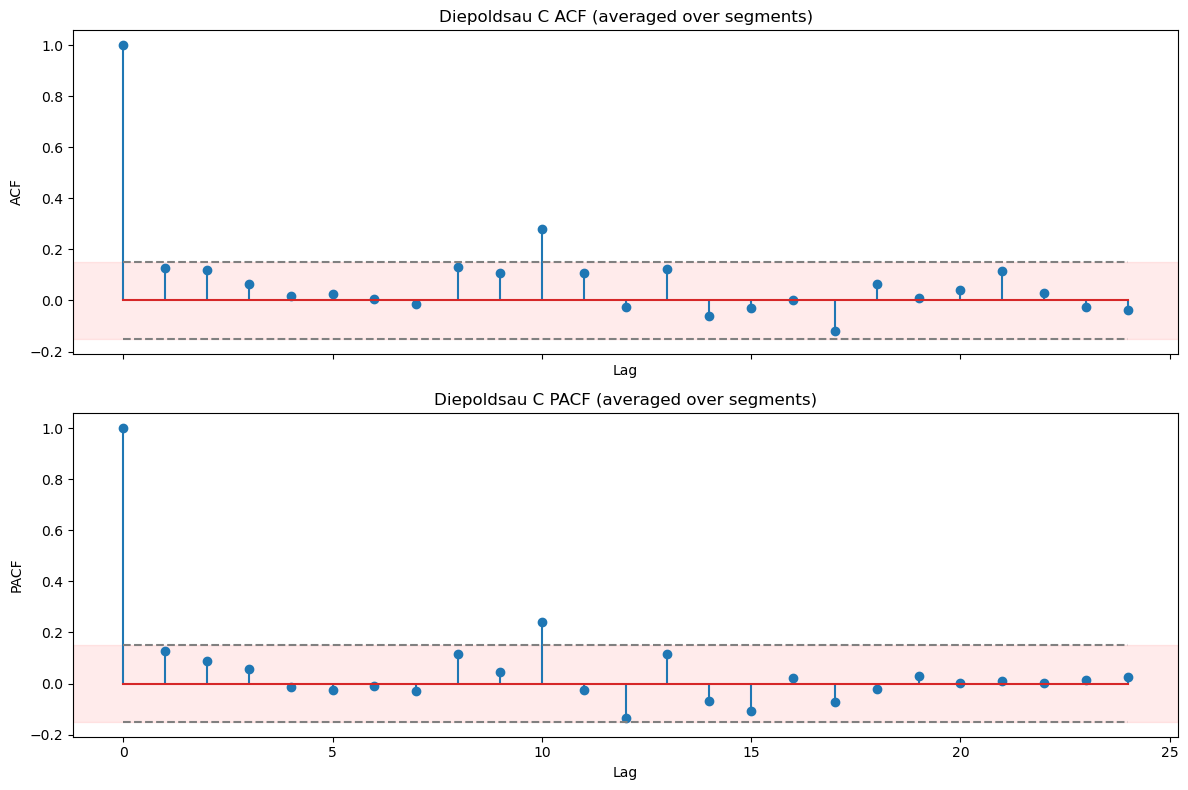


=== Gisingen Q ===
  n after detrend+deseason: 564


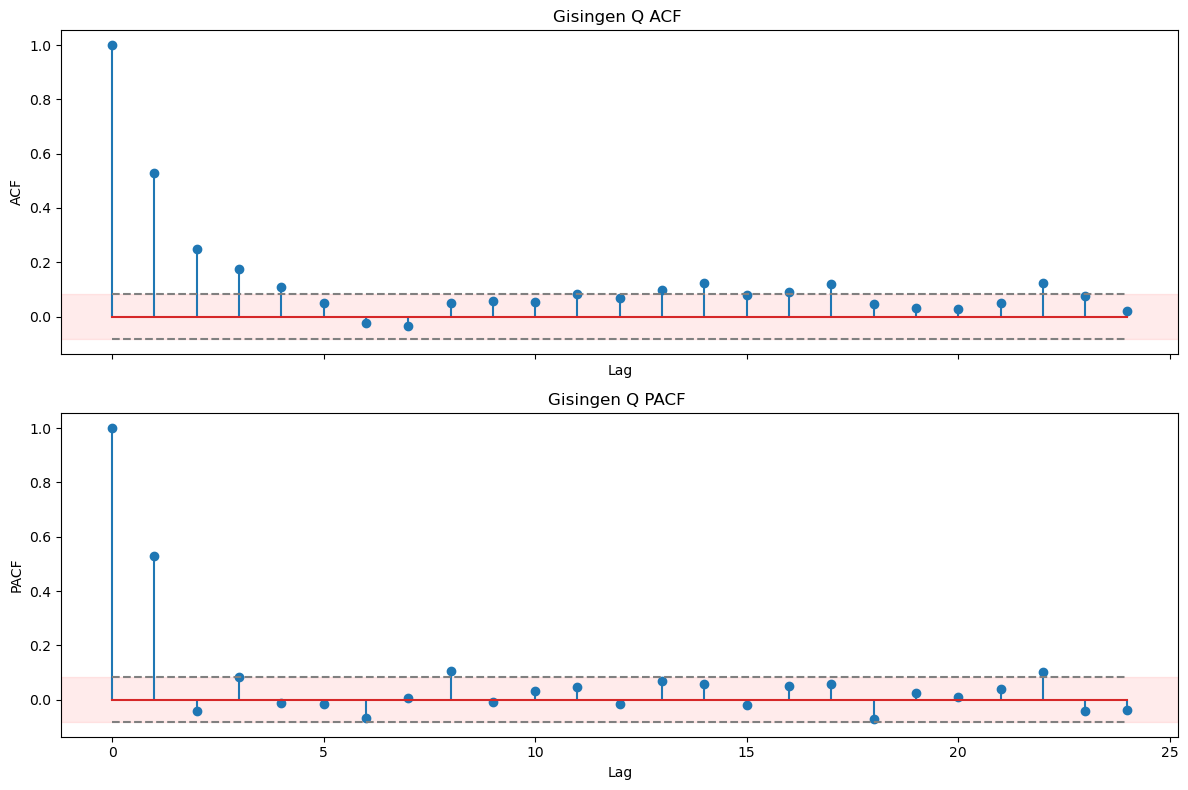


=== Gisingen C ===
  n after detrend+deseason: 192
  Gap detected at 2009-01-01 – splitting series.
  Segment "before gap": n=60
  Segment "after gap": n=132


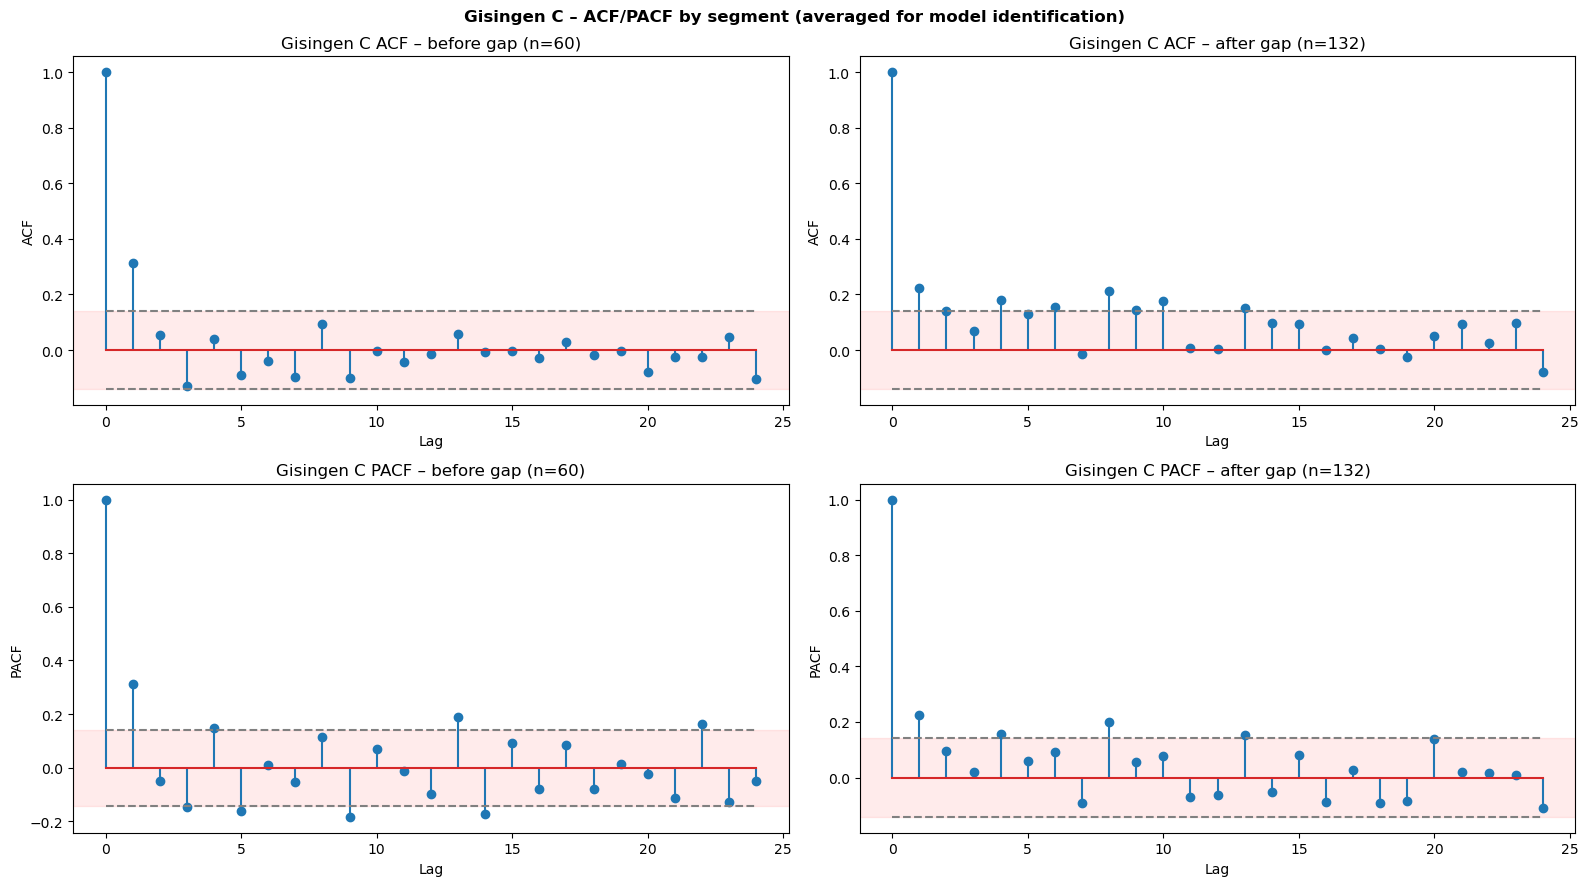

  Pearson r between segment ACFs: 0.557  (different memory structure)


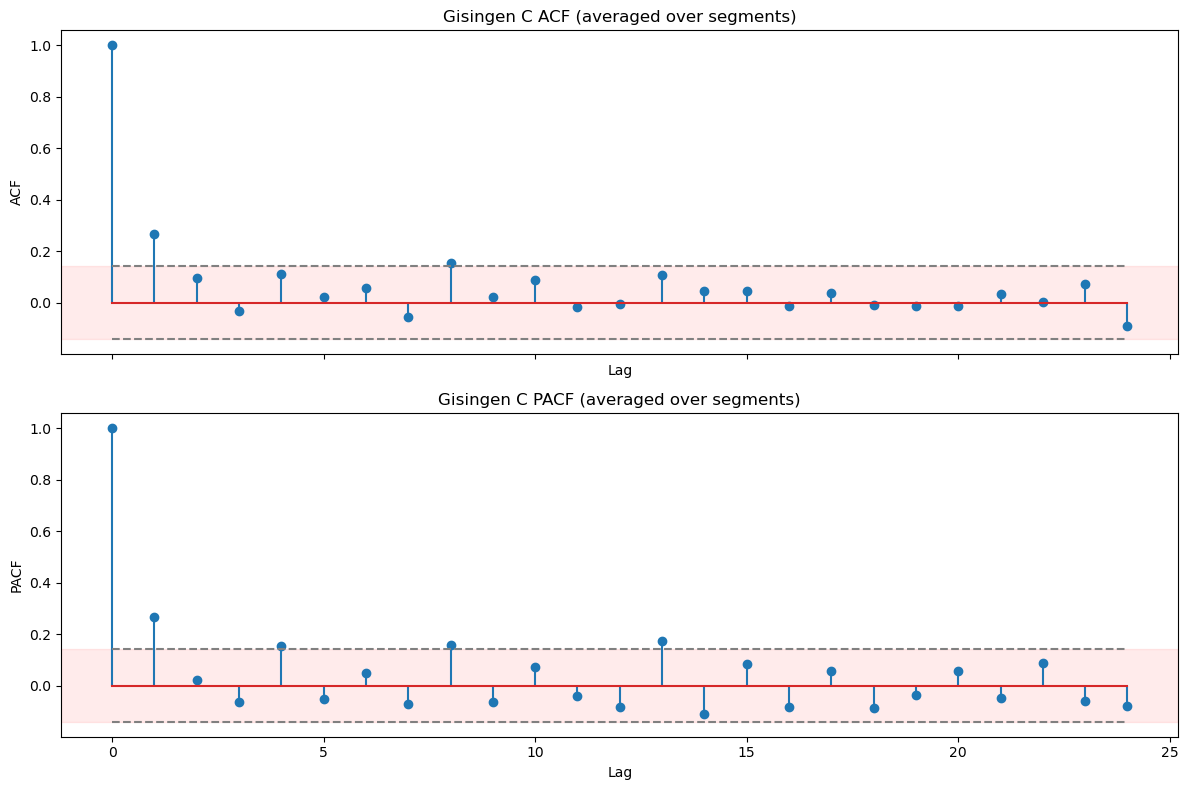

In [7]:
# ── Seasonal standardisation ──────────────────────────────────────────────────
# Method 1 (lecture notes §6.5.3): subtract per-month mean, divide by per-month std.
# This removes both the periodic mean and the periodic variance, producing a
# stationary z_t ∼ N(0,1) series suitable for AR/ARMA fitting.

def seasonal_standardise(series):
    """Return (standardised series, monthly means, monthly stds)."""
    df = series.to_frame(name='val')
    df['month'] = df.index.month
    monthly_mean = df.groupby('month')['val'].transform('mean')
    monthly_std  = df.groupby('month')['val'].transform('std')
    z = (df['val'] - monthly_mean) / monthly_std
    return z, df.groupby('month')['val'].mean(), df.groupby('month')['val'].std()

# Known data gaps (professor's email):
#   Diepoldsau SSC: 2019  →  split before 2019 / from 2019
#   Gisingen   SSC: 2009  →  split before 2009 / from 2009
GAP_CONFIG = {
    'C_Diepoldsau': pd.Timestamp('2019-01-01'),
    'C_Gisingen':   pd.Timestamp('2009-01-01'),
}

def gap_aware_acf_pacf(series, max_lag, gap_date=None):
    """
    If gap_date is given: compute ACF/PACF on each segment separately,
    average the two estimates, and return also the individual segment results.
    Otherwise compute on the full series.
    Returns (acf_avg, pacf_avg, conf, segments_info).
    """
    n_full = len(series.dropna())
    conf = 1.96 / np.sqrt(n_full)

    if gap_date is None:
        s = series.dropna()
        acf_v  = acf(s,  nlags=max_lag, fft=False, missing='drop')
        pacf_v = pacf(s, nlags=max_lag, method='ywm')
        return acf_v, pacf_v, conf, None

    before = series[series.index < gap_date].dropna()
    after  = series[series.index >= gap_date].dropna()
    segments = {}
    acfs, pacfs = [], []
    for label, seg in [('before gap', before), ('after gap', after)]:
        if len(seg) < max_lag + 2:
            print(f'  Segment "{label}" too short ({len(seg)} obs), skipping.')
            continue
        a  = acf(seg,  nlags=max_lag, fft=False, missing='drop')
        p_ = pacf(seg, nlags=max_lag, method='ywm')
        acfs.append(a);  pacfs.append(p_)
        segments[label] = {'acf': a, 'pacf': p_, 'n': len(seg)}
        print(f'  Segment "{label}": n={len(seg)}')

    if len(acfs) == 0:
        raise ValueError('No valid segments found.')
    acf_avg  = np.mean(acfs,  axis=0)
    pacf_avg = np.mean(pacfs, axis=0)
    return acf_avg, pacf_avg, conf, segments

max_lag = 24

# Containers for the deseasonalised (z) series used in ARMA fitting
z_series = {}

for key, raw_series in detrended_series.items():
    variable, station = key.split('_', 1)

    # ── Step 1: seasonal standardisation ──────────────────────────────────────
    z, m_mean, m_std = seasonal_standardise(raw_series.dropna())
    z_series[key] = z
    print(f'\n=== {station} {variable} ===')
    print(f'  n after detrend+deseason: {len(z)}')

    # ── Step 2: gap-aware ACF/PACF ────────────────────────────────────────────
    gap_date = GAP_CONFIG.get(key, None)
    if gap_date is not None:
        print(f'  Gap detected at {gap_date.date()} – splitting series.')
    acf_avg, pacf_avg, conf, segments = gap_aware_acf_pacf(z, max_lag, gap_date)

    # ── Step 3: plot ──────────────────────────────────────────────────────────
    lags = np.arange(len(acf_avg))

    # If gap present: also show the two segment ACFs for comparison
    if segments:
        fig, axes = plt.subplots(2, 2, figsize=(16, 9))
        for col, (label, seg_data) in enumerate(segments.items()):
            axes[0, col].stem(lags, seg_data['acf'])
            axes[0, col].hlines([conf, -conf], 0, max_lag, colors='gray', linestyles='dashed')
            axes[0, col].axhspan(-conf, conf, alpha=0.08, color='red')
            axes[0, col].set_title(f'{station} {variable} ACF – {label} (n={seg_data["n"]})')
            axes[0, col].set_xlabel('Lag'); axes[0, col].set_ylabel('ACF')

            axes[1, col].stem(lags, seg_data['pacf'])
            axes[1, col].hlines([conf, -conf], 0, max_lag, colors='gray', linestyles='dashed')
            axes[1, col].axhspan(-conf, conf, alpha=0.08, color='red')
            axes[1, col].set_title(f'{station} {variable} PACF – {label} (n={seg_data["n"]})')
            axes[1, col].set_xlabel('Lag'); axes[1, col].set_ylabel('PACF')
        fig.suptitle(f'{station} {variable} – ACF/PACF by segment (averaged for model identification)', fontweight='bold')
        plt.tight_layout(); plt.show()

        # Are the two segments meaningfully different?
        s1_acf = list(segments.values())[0]['acf'][1:]
        s2_acf = list(segments.values())[1]['acf'][1:]
        r, _ = pearsonr(s1_acf, s2_acf)
        print(f'  Pearson r between segment ACFs: {r:.3f}  '
              f'({"similar" if r > 0.8 else "different"} memory structure)')

    # Averaged (or full) ACF / PACF
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    title_suffix = '(averaged over segments)' if segments else ''

    axes[0].stem(lags, acf_avg)
    axes[0].hlines([conf, -conf], 0, max_lag, colors='gray', linestyles='dashed')
    axes[0].axhspan(-conf, conf, alpha=0.08, color='red')
    axes[0].set_title(f'{station} {variable} ACF {title_suffix}')
    axes[0].set_xlabel('Lag'); axes[0].set_ylabel('ACF')

    axes[1].stem(lags, pacf_avg)
    axes[1].hlines([conf, -conf], 0, max_lag, colors='gray', linestyles='dashed')
    axes[1].axhspan(-conf, conf, alpha=0.08, color='red')
    axes[1].set_title(f'{station} {variable} PACF {title_suffix}')
    axes[1].set_xlabel('Lag'); axes[1].set_ylabel('PACF')

    plt.tight_layout(); plt.show()


# 2.2 AR and ARMA model fitting
This section fits AR and ARMA models to the detrended discharge (Q) and concentration (C) series for each station. The model orders are first selected based on the ACF and PACF plots (p from PACF cutoff, q from ACF cutoff), then fitted and compared using AIC and BIC. The chosen orders reflect the structure observed in the ACF/PACF plots.

In [8]:
# ── Model fitting on the seasonally standardised series ───────────────────────
# Per professor: model order must be ≤ 12. We scan AR(1..4) and ARMA(1..4, 1..3)
# to keep parsimony. The z_series are already detrended AND deseasonalised.

def select_order_from_acf_pacf(series, max_lag=24, max_order=12):
    """Select ARMA(p,q) order from ACF/PACF; capped at max_order."""
    n = len(series.dropna())
    conf = 1.96 / np.sqrt(n)
    acf_v  = acf(series.dropna(),  nlags=max_lag, fft=False, missing='drop')
    pacf_v = pacf(series.dropna(), nlags=max_lag, method='ywm')
    p = 0
    for lag in range(1, max_lag + 1):
        if abs(pacf_v[lag]) > conf:
            p = lag
        else:
            break
    q = 0
    for lag in range(1, max_lag + 1):
        if abs(acf_v[lag]) > conf:
            q = lag
        else:
            break
    return min(p, max_order), min(q, max_order)


def candidate_models(y, max_ar=4, max_ma=3):
    """Fit AR(p) and ARMA(p,q) candidates; return BIC-sorted DataFrame."""
    y = np.asarray(y.dropna(), dtype=float)
    results = []
    for p in range(1, max_ar + 1):
        try:
            m = ARIMA(y, order=(p, 0, 0)).fit()
            results.append(('AR', p, 0, m.aic, m.bic))
        except Exception as e:
            print(f'  AR({p}) failed: {e}')
    for p in range(1, max_ar + 1):
        for q in range(1, max_ma + 1):
            try:
                m = ARIMA(y, order=(p, 0, q)).fit()
                results.append(('ARMA', p, q, m.aic, m.bic))
            except Exception as e:
                print(f'  ARMA({p},{q}) failed: {e}')
    if not results:
        return pd.DataFrame(columns=['model','p','q','aic','bic'])
    return pd.DataFrame(results, columns=['model','p','q','aic','bic']).sort_values(['bic','aic'])


fitted_models = {}

for key, z in z_series.items():
    variable, station = key.split('_', 1)
    print(f'\n===== {station} {variable} =====')
    if len(z.dropna()) < 10:
        print('  Too few observations – skipping.')
        continue

    p_sug, q_sug = select_order_from_acf_pacf(z)
    print(f'  ACF/PACF suggested: p={p_sug}, q={q_sug}')

    selection = candidate_models(z)
    if selection.empty:
        print('  No model could be fitted.')
        continue
    display(selection.head(12))

    # Best AR (parsimonious)
    best_ar = selection[selection['q'] == 0].head(1)
    if not best_ar.empty:
        ar_p = int(best_ar['p'].iloc[0])
        try:
            fm = ARIMA(z.dropna(), order=(ar_p, 0, 0)).fit()
            fitted_models[f'{key}_AR'] = fm
            print(f'  → Best AR: AR({ar_p})  AIC={best_ar.aic.iloc[0]:.1f}  BIC={best_ar.bic.iloc[0]:.1f}')
        except Exception as e:
            print(f'  AR({ar_p}) refit failed: {e}')

    # Best ARMA (parsimonious)
    best_arma = selection[selection['q'] > 0].head(1)
    if not best_arma.empty:
        arma_p = int(best_arma['p'].iloc[0])
        arma_q = int(best_arma['q'].iloc[0])
        try:
            fm = ARIMA(z.dropna(), order=(arma_p, 0, arma_q)).fit()
            fitted_models[f'{key}_ARMA'] = fm
            print(f'  → Best ARMA: ARMA({arma_p},{arma_q})  AIC={best_arma.aic.iloc[0]:.1f}  BIC={best_arma.bic.iloc[0]:.1f}')
        except Exception as e:
            print(f'  ARMA({arma_p},{arma_q}) refit failed: {e}')



===== Diepoldsau Q =====
  ACF/PACF suggested: p=1, q=7


c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,model,p,q,aic,bic
0,AR,1,0,1220.335309,1233.020842
4,ARMA,1,1,1218.435144,1235.349188
1,AR,2,0,1219.713609,1236.627653
2,AR,3,0,1215.768773,1236.911328
5,ARMA,1,2,1217.128266,1238.270821
7,ARMA,2,1,1218.663287,1239.805842
8,ARMA,2,2,1216.853933,1242.224999
6,ARMA,1,3,1217.284696,1242.655762
10,ARMA,3,1,1217.520529,1242.891595
3,AR,4,0,1217.601771,1242.972837


  → Best AR: AR(1)  AIC=1220.3  BIC=1233.0
  → Best ARMA: ARMA(1,1)  AIC=1218.4  BIC=1235.3

===== Diepoldsau C =====
  ACF/PACF suggested: p=0, q=0


c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\base\

...

  → Best AR: AR(1)  AIC=1410.8  BIC=1423.8
  → Best ARMA: ARMA(1,1)  AIC=1411.4  BIC=1428.7

===== Gisingen C =====
  ACF/PACF suggested: p=1, q=1


c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,model,p,q,aic,bic
0,AR,1,0,524.510018,534.282504
8,ARMA,2,2,515.218028,534.763000
5,ARMA,1,2,521.858932,538.146408
12,ARMA,3,3,512.330636,538.390599
1,AR,2,0,525.923627,538.953609
4,ARMA,1,1,525.991137,539.021119
7,ARMA,2,1,523.308682,539.596158
6,ARMA,1,3,523.839819,543.384792
2,AR,3,0,527.612674,543.900151
10,ARMA,3,1,524.688775,544.233747


c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dat

  → Best AR: AR(1)  AIC=524.5  BIC=534.3
  → Best ARMA: ARMA(2,2)  AIC=515.2  BIC=534.8


# 3. Timeseries application & evaluation
This section evaluates the fitted AR/ARMA models by comparing empirical and theoretical ACFs, analyzing residual autocorrelations, and testing for independence and normality of residuals.


===== Diepoldsau Q Evaluation =====


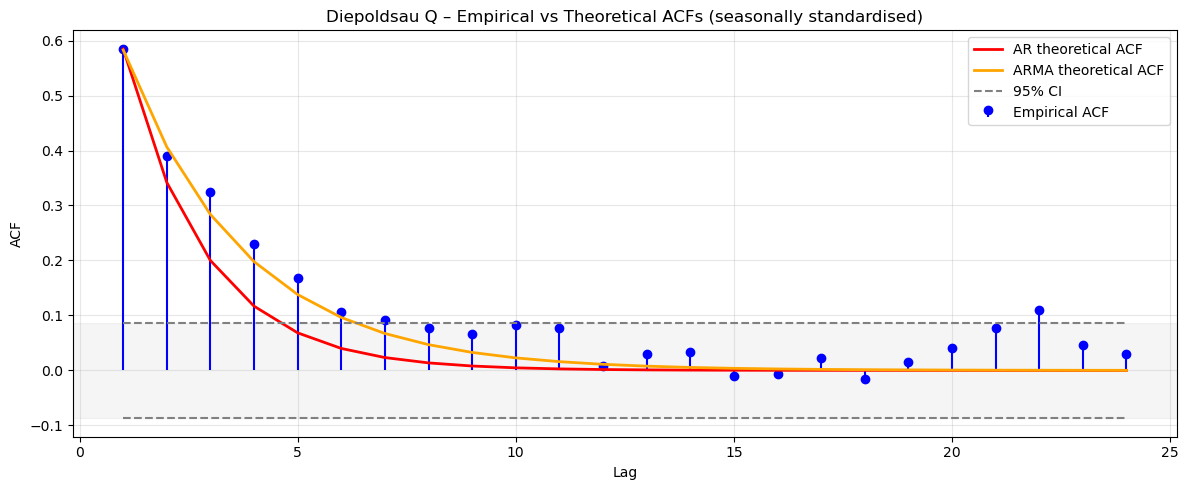

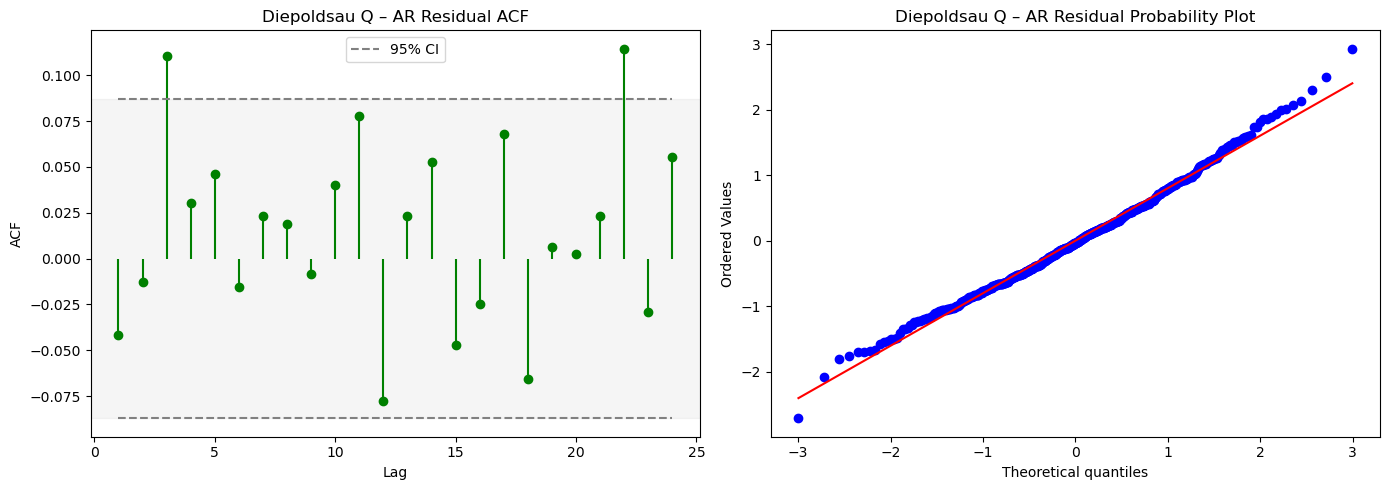

  AR Ljung-Box (lag=24): stat=33.86, p=0.0871  → residuals independent ✓
  AR Shapiro-Wilk normality:  stat=0.9936, p=0.0297  → residuals NOT normal ✗
  AR residual ACF significant at lags: [3, 22]



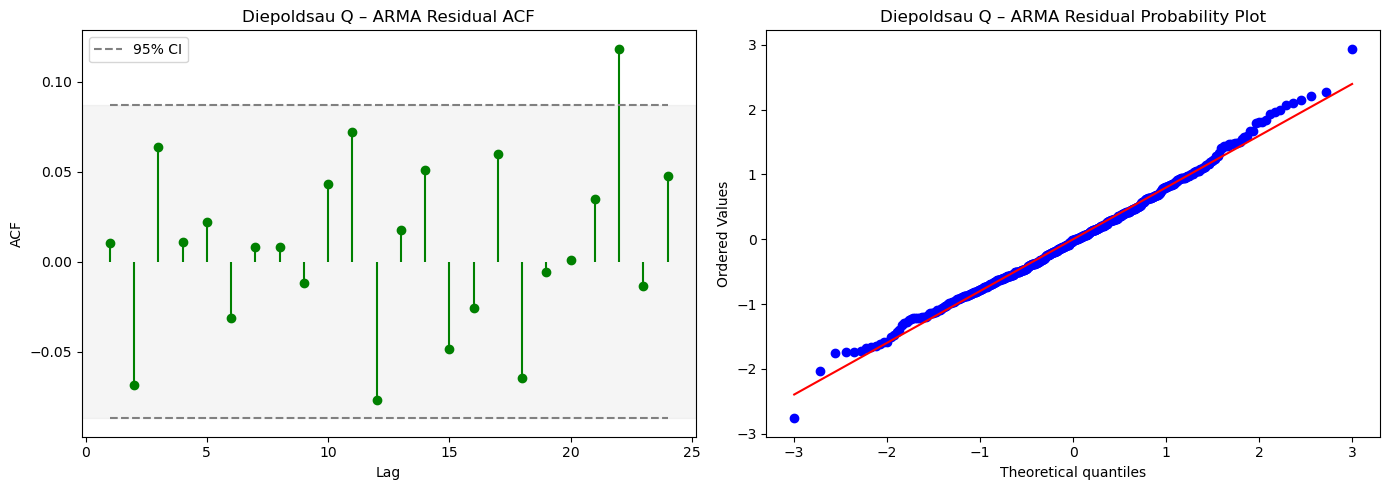

  ARMA Ljung-Box (lag=24): stat=28.83, p=0.2264  → residuals independent ✓
  ARMA Shapiro-Wilk normality:  stat=0.9940, p=0.0424  → residuals NOT normal ✗
  ARMA residual ACF significant at lags: [22]


===== Diepoldsau C Evaluation =====


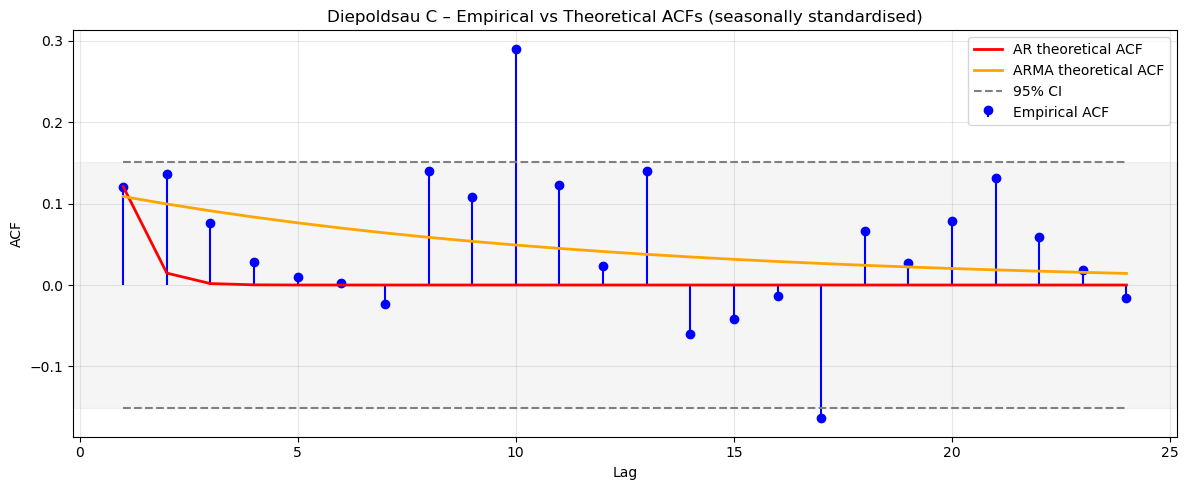

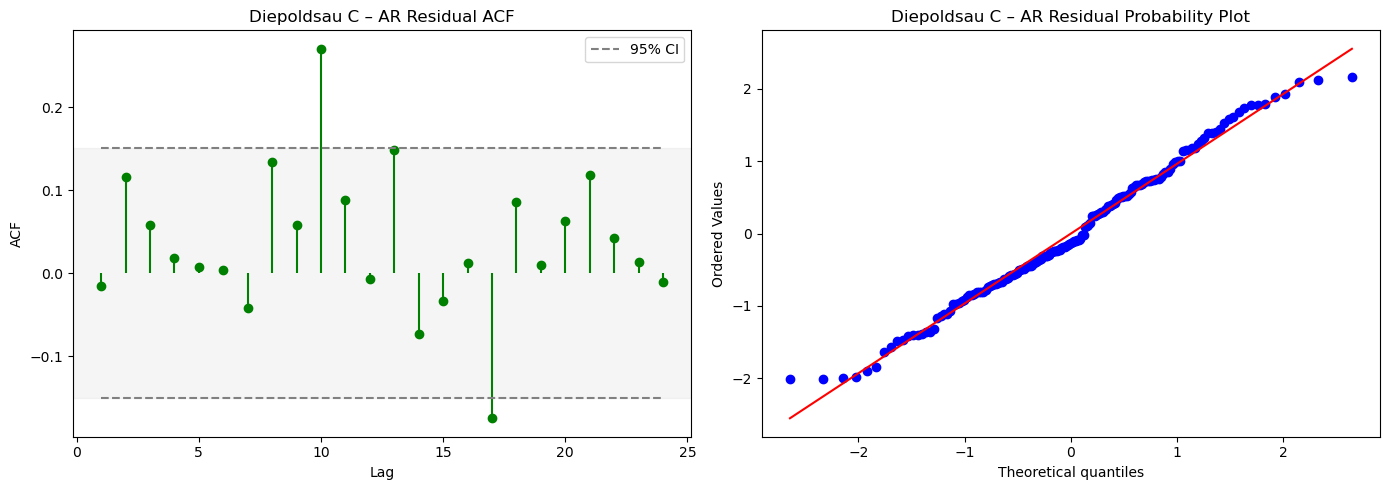

  AR Ljung-Box (lag=24): stat=38.40, p=0.0316  → residuals NOT independent ✗
  AR Shapiro-Wilk normality:  stat=0.9872, p=0.1263  → residuals normal ✓
  AR residual ACF significant at lags: [10, 17]



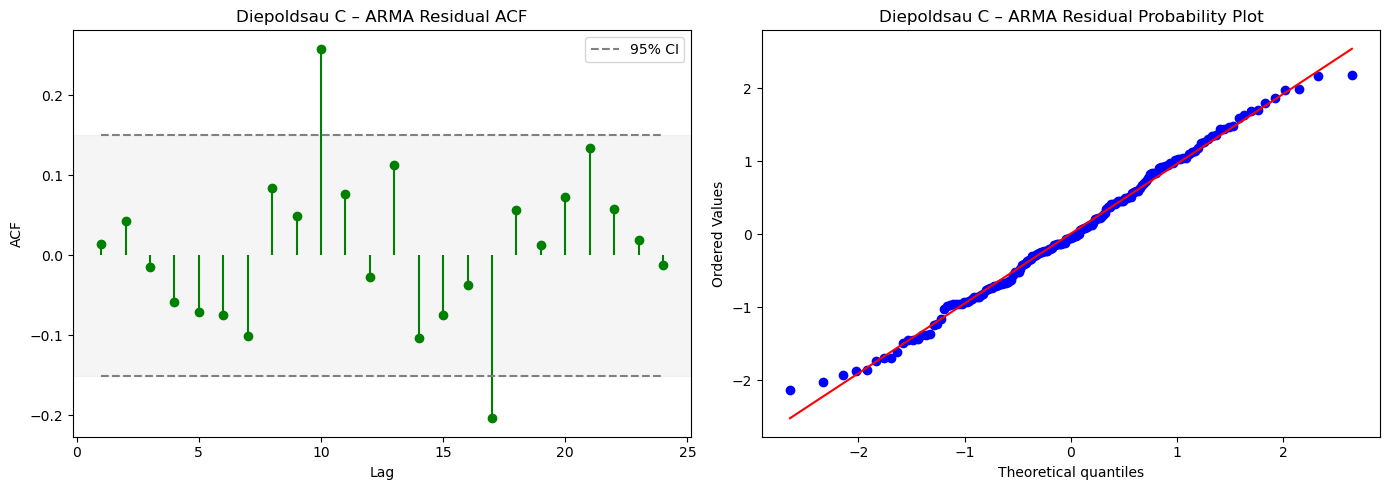

  ARMA Ljung-Box (lag=24): stat=39.31, p=0.0253  → residuals NOT independent ✗
  ARMA Shapiro-Wilk normality:  stat=0.9919, p=0.4610  → residuals normal ✓
  ARMA residual ACF significant at lags: [10, 17]


===== Gisingen Q Evaluation =====


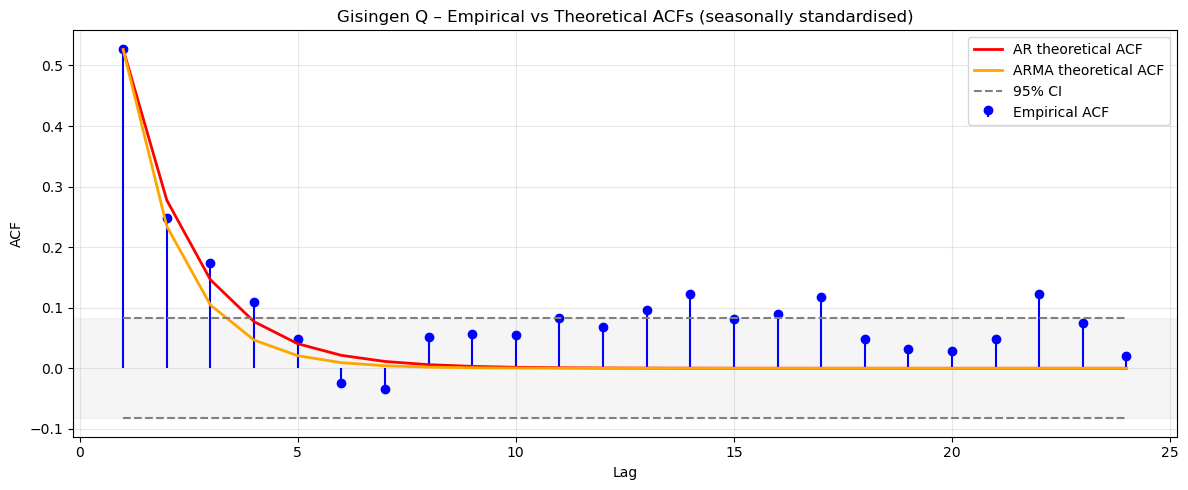

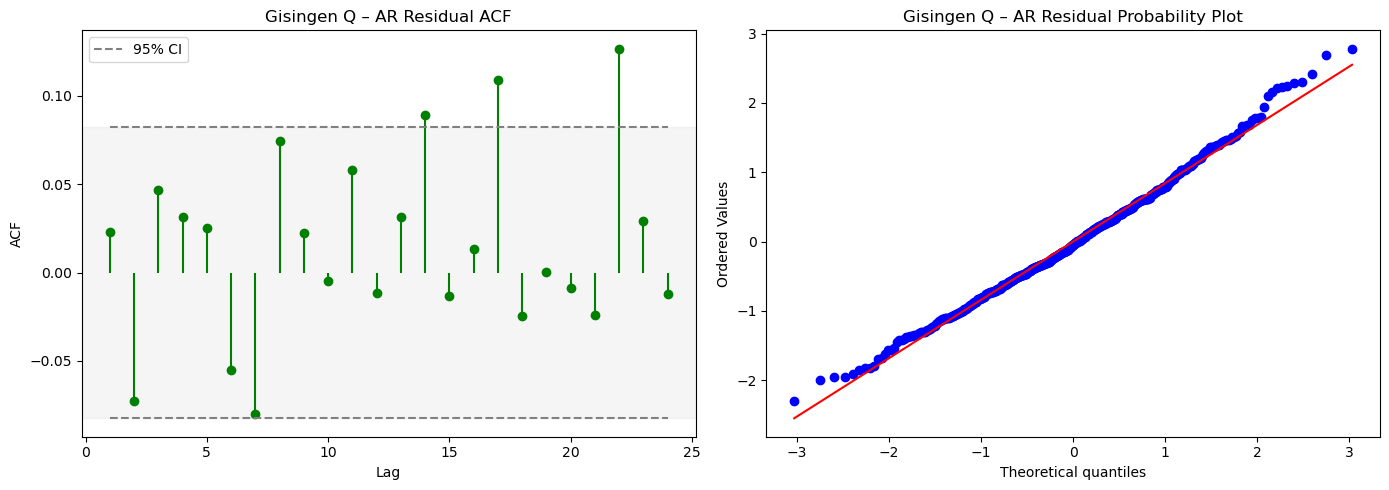

  AR Ljung-Box (lag=24): stat=39.50, p=0.0242  → residuals NOT independent ✗
  AR Shapiro-Wilk normality:  stat=0.9938, p=0.0211  → residuals NOT normal ✗
  AR residual ACF significant at lags: [14, 17, 22]



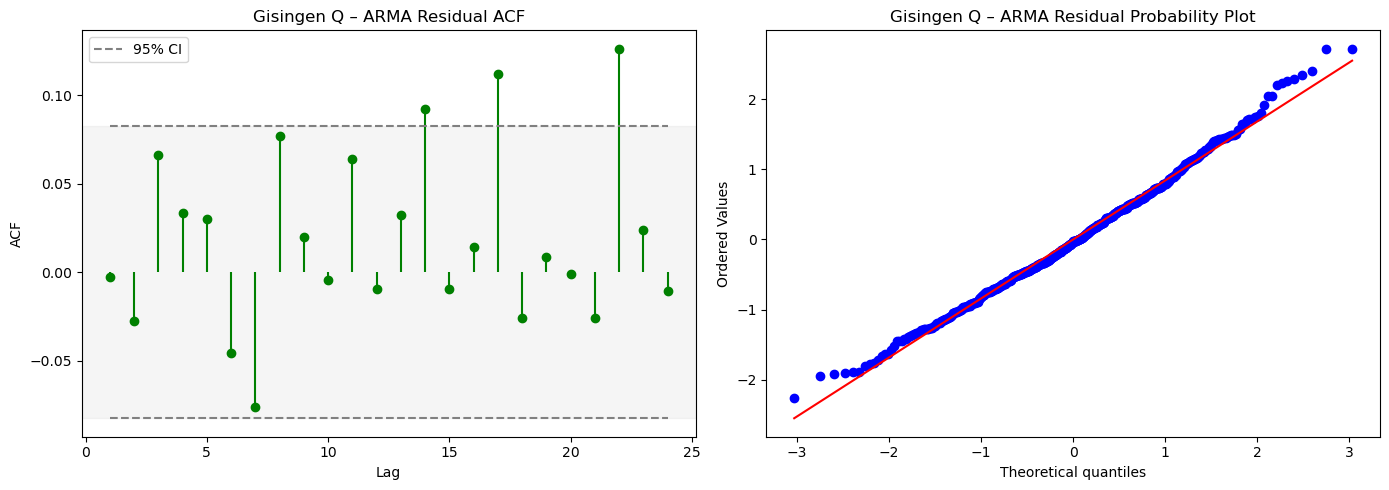

  ARMA Ljung-Box (lag=24): stat=38.28, p=0.0325  → residuals NOT independent ✗
  ARMA Shapiro-Wilk normality:  stat=0.9939, p=0.0219  → residuals NOT normal ✗
  ARMA residual ACF significant at lags: [14, 17, 22]


===== Gisingen C Evaluation =====


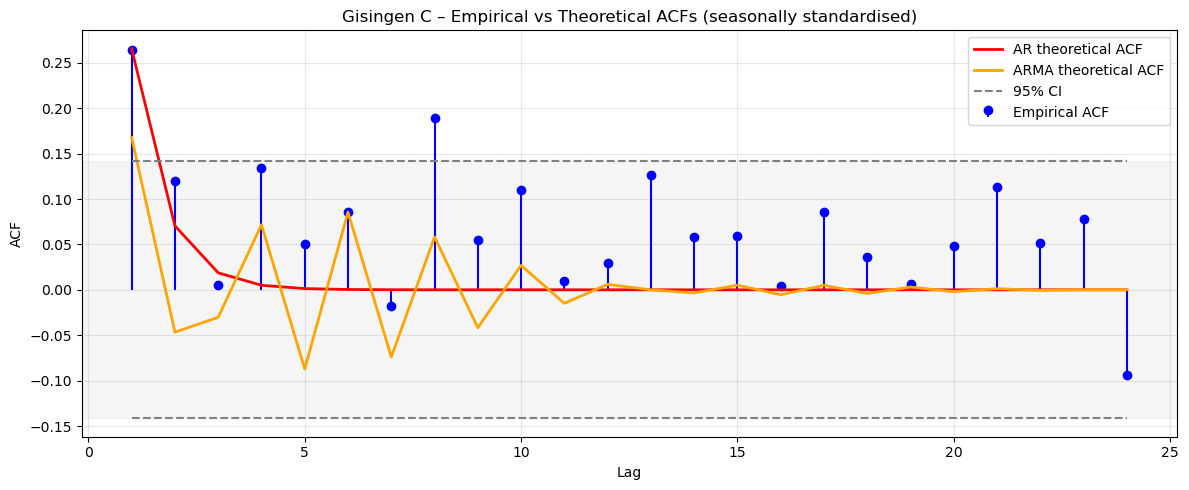

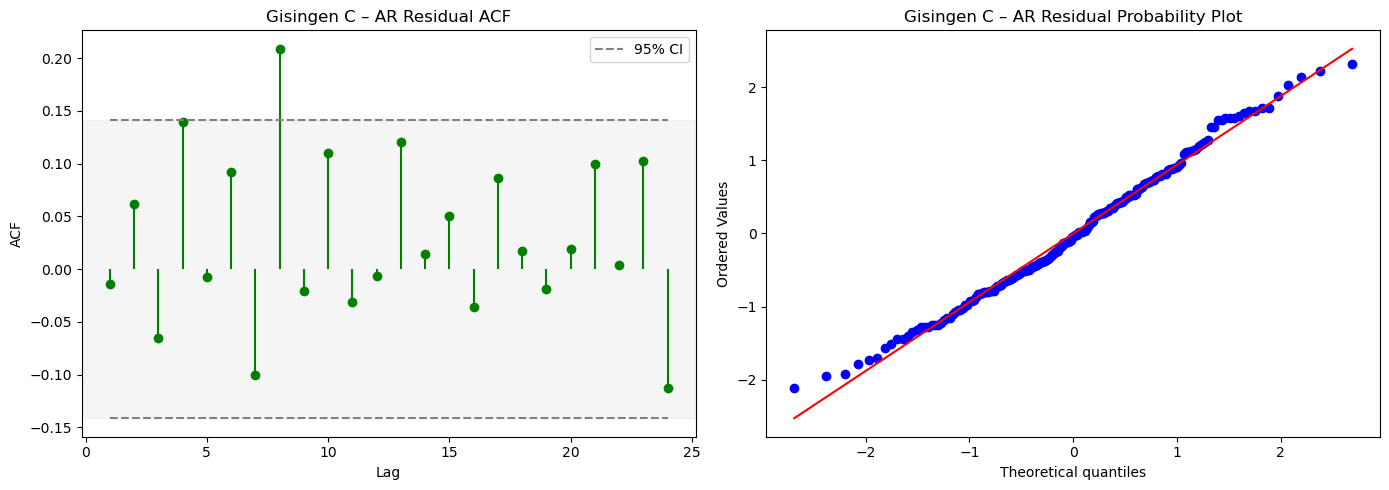

  AR Ljung-Box (lag=24): stat=33.82, p=0.0879  → residuals independent ✓
  AR Shapiro-Wilk normality:  stat=0.9901, p=0.2098  → residuals normal ✓
  AR residual ACF significant at lags: [8]



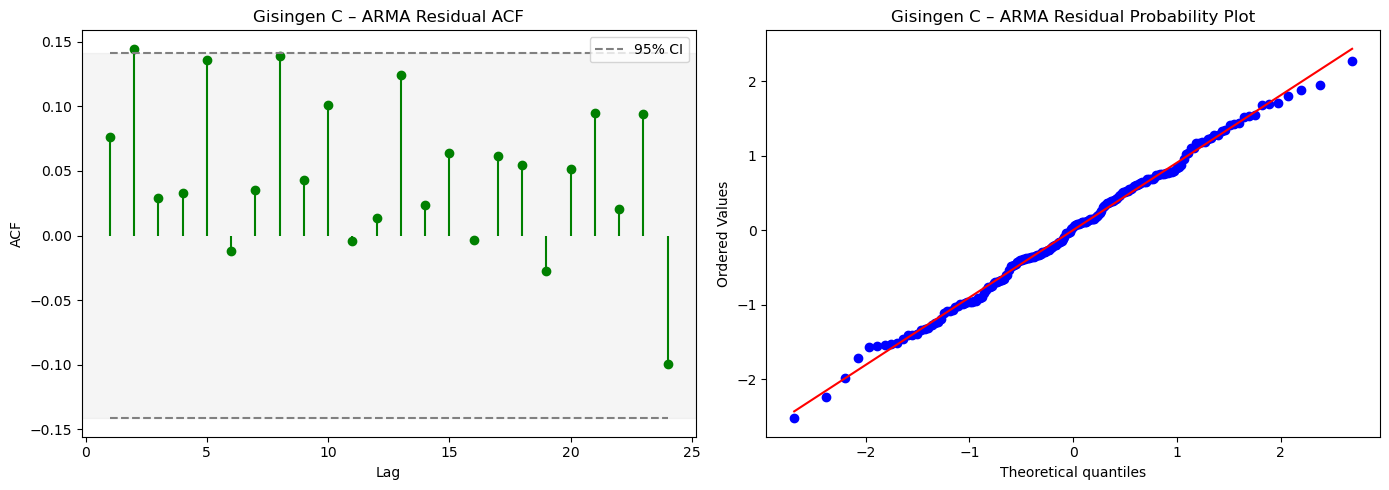

  ARMA Ljung-Box (lag=24): stat=28.51, p=0.2390  → residuals independent ✓
  ARMA Shapiro-Wilk normality:  stat=0.9954, p=0.8304  → residuals normal ✓
  ARMA residual ACF significant at lags: [2]



In [9]:
# ── Model evaluation ─────────────────────────────────────────────────────────
from statsmodels.tsa.arima_process import ArmaProcess
from scipy.stats import shapiro

max_lag = 24

def theoretical_acf(model_obj, max_lag):
    """Compute theoretical ACF from fitted ARIMA model using ArmaProcess.
    Returns None if the process is non-stationary (roots >= 1)."""
    ar = np.r_[1, -model_obj.arparams]   # statsmodels sign convention
    ma = np.r_[1,  model_obj.maparams]
    # Check stationarity: all roots of AR polynomial must be inside unit circle
    if len(ar) > 1:
        roots = np.roots(ar)
        if np.any(np.abs(roots) >= 1.0):
            print(f'  Warning: fitted AR params are non-stationary (max root={np.max(np.abs(roots)):.3f}) '
                  f'– theoretical ACF cannot be computed.')
            return None
    return ArmaProcess(ar, ma).acf(max_lag + 1)[1:]

for key, z in z_series.items():
    variable, station = key.split('_', 1)
    z_clean = z.dropna()
    n = len(z_clean)
    conf = 1.96 / np.sqrt(n)
    emp_acf = acf(z_clean, nlags=max_lag, fft=False, missing='drop')
    lags = np.arange(1, max_lag + 1)

    ar_model   = fitted_models.get(f'{key}_AR')
    arma_model = fitted_models.get(f'{key}_ARMA')

    print(f'\n===== {station} {variable} Evaluation =====')

    # ── (a) Empirical vs theoretical ACF ──────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.stem(lags, emp_acf[1:], label='Empirical ACF', linefmt='b-', markerfmt='bo', basefmt=' ')

    for model_obj, label, color in [
        (ar_model,   'AR theoretical ACF',   'red'),
        (arma_model, 'ARMA theoretical ACF', 'orange'),
    ]:
        if model_obj is not None:
            theo = theoretical_acf(model_obj, max_lag)
            if theo is not None:
                ax.plot(lags, theo, label=label, color=color, linewidth=2)

    ax.hlines([conf, -conf], 1, max_lag, colors='gray', linestyles='dashed', label='95% CI')
    ax.axhspan(-conf, conf, alpha=0.08, color='gray')
    ax.set_title(f'{station} {variable} – Empirical vs Theoretical ACFs (seasonally standardised)')
    ax.set_xlabel('Lag'); ax.set_ylabel('ACF'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    # ── (b) Residual ACF + Ljung-Box + normality per model ───────────────────
    for model_type, model_obj in [('AR', ar_model), ('ARMA', arma_model)]:
        if model_obj is None:
            continue
        residuals = model_obj.resid
        res_acf   = acf(residuals, nlags=max_lag, fft=False, missing='drop')

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].stem(lags, res_acf[1:], linefmt='g-', markerfmt='go', basefmt=' ')
        axes[0].hlines([conf, -conf], 1, max_lag, colors='gray', linestyles='dashed', label='95% CI')
        axes[0].axhspan(-conf, conf, alpha=0.08, color='gray')
        axes[0].set_title(f'{station} {variable} – {model_type} Residual ACF')
        axes[0].set_xlabel('Lag'); axes[0].set_ylabel('ACF'); axes[0].legend()

        probplot(residuals, dist='norm', plot=axes[1])
        axes[1].set_title(f'{station} {variable} – {model_type} Residual Probability Plot')

        plt.tight_layout(); plt.show()

        lb = acorr_ljungbox(residuals, lags=[max_lag], return_df=True)
        lb_p = lb['lb_pvalue'].iloc[0]
        print(f'  {model_type} Ljung-Box (lag={max_lag}): stat={lb["lb_stat"].iloc[0]:.2f}, '
              f'p={lb_p:.4f}  → residuals {"independent ✓" if lb_p > 0.05 else "NOT independent ✗"}')

        sw_stat, sw_p = shapiro(residuals)
        print(f'  {model_type} Shapiro-Wilk normality:  stat={sw_stat:.4f}, '
              f'p={sw_p:.4f}  → residuals {"normal ✓" if sw_p > 0.05 else "NOT normal ✗"}')

        sig_lags = [lag for lag in range(1, max_lag + 1) if abs(res_acf[lag]) > conf]
        if sig_lags:
            print(f'  {model_type} residual ACF significant at lags: {sig_lags}')
        else:
            print(f'  {model_type} residual ACF: all lags within 95% CI ✓')
        print()


In [10]:
# PPCC (Probability Plot Correlation Coefficient) for model residuals
from scipy.stats import probplot, shapiro
alpha = 0.05
print("="*60)
print("PPCC FOR MODEL RESIDUALS (notebook v4 (2))")
print(f"Decision alpha = {alpha:.2f}")
print("="*60)
rows = []
for key, model in fitted_models.items():
    try:
        resid = pd.Series(model.resid).dropna()
    except Exception:
        try:
            resid = pd.Series(model.resid())
        except Exception:
            print(f"{key}: could not extract residuals")
            continue
    if len(resid) < 3:
        print(f"{key}: too few residuals ({len(resid)})")
        continue
    (osm, osr), (slope, intercept, r) = probplot(resid, dist='norm', fit=True)
    sw_stat, sw_p = shapiro(resid)
    normal = sw_p > alpha
    print(f"{key}: PPCC={r:.4f}  Shapiro-p={sw_p:.4f}  normal={'YES' if normal else 'NO'}  n={len(resid)}")
    rows.append({
        'model': key,
        'order': getattr(model.model, 'order', None),
        'ppcc': float(r),
        'sw_p': float(sw_p),
        'normal': bool(normal),
        'n': len(resid)
    })

fitted_models_ppcc = pd.DataFrame(rows)

# display the summary table
fitted_models_ppcc

PPCC FOR MODEL RESIDUALS (notebook v4 (2))
Decision alpha = 0.05
Q_Diepoldsau_AR: PPCC=0.9964  Shapiro-p=0.0297  normal=NO  n=507
Q_Diepoldsau_ARMA: PPCC=0.9965  Shapiro-p=0.0424  normal=NO  n=507
C_Diepoldsau_AR: PPCC=0.9955  Shapiro-p=0.1263  normal=YES  n=169
C_Diepoldsau_ARMA: PPCC=0.9975  Shapiro-p=0.4610  normal=YES  n=169
Q_Gisingen_AR: PPCC=0.9970  Shapiro-p=0.0211  normal=NO  n=564
Q_Gisingen_ARMA: PPCC=0.9971  Shapiro-p=0.0219  normal=NO  n=564
C_Gisingen_AR: PPCC=0.9963  Shapiro-p=0.2098  normal=YES  n=192
C_Gisingen_ARMA: PPCC=0.9982  Shapiro-p=0.8304  normal=YES  n=192


,model,order,ppcc,sw_p,normal,n
0,Q_Diepoldsau_AR,"(1, 0, 0)",0.996359,0.029732,False,507
1,Q_Diepoldsau_ARMA,"(1, 0, 1)",0.996549,0.042405,False,507
2,C_Diepoldsau_AR,"(1, 0, 0)",0.995461,0.126310,True,169
3,C_Diepoldsau_ARMA,"(1, 0, 1)",0.997541,0.460987,True,169
4,Q_Gisingen_AR,"(1, 0, 0)",0.997010,0.021052,False,564
5,Q_Gisingen_ARMA,"(1, 0, 1)",0.997089,0.021896,False,564
6,C_Gisingen_AR,"(1, 0, 0)",0.996316,0.209821,True,192
7,C_Gisingen_ARMA,"(2, 0, 2)",0.998159,0.830436,True,192


In [11]:
# PPCC critical-value test (Monte Carlo)
from scipy.stats import probplot
alpha = 0.05
n_sims = 2000
print("="*60)
print(f"PPCC CRITICAL-VALUE TEST (alpha={alpha:.2f}, sims={n_sims})")
print("="*60)

crit_cache = {}
rows = []
for key, model in fitted_models.items():
    try:
        resid = pd.Series(model.resid).dropna()
    except Exception:
        try:
            resid = pd.Series(model.resid())
        except Exception:
            print(f"{key}: could not extract residuals")
            continue
    n = len(resid)
    if n < 5:
        print(f"{key}: too few residuals (n={n}), skipping")
        continue
    (osm, osr), (slope, intercept, r_obs) = probplot(resid, dist='norm', fit=True)

    if n in crit_cache:
        r_crit = crit_cache[n]
    else:
        rs = np.empty(n_sims)
        for i in range(n_sims):
            sim = np.random.normal(size=n)
            (_, _), (_, _, r_sim) = probplot(sim, dist='norm', fit=True)
            rs[i] = r_sim
        r_crit = np.quantile(rs, 1 - alpha)
        crit_cache[n] = float(r_crit)

    accept = r_obs >= r_crit
    decision = 'NOT reject (normal)' if accept else 'reject (not normal)'
    print(f"{key}: r={r_obs:.4f}  r_crit={r_crit:.4f}  decision: {decision}  n={n}")

    rows.append({'model': key, 'order': getattr(model.model, 'order', None), 'r': float(r_obs), 'r_crit': float(r_crit), 'accept': bool(accept), 'n': n})

fitted_models_ppcc_crit = pd.DataFrame(rows)

# show summary
fitted_models_ppcc_crit

PPCC CRITICAL-VALUE TEST (alpha=0.05, sims=2000)
Q_Diepoldsau_AR: r=0.9964  r_crit=0.9993  decision: reject (not normal)  n=507
Q_Diepoldsau_ARMA: r=0.9965  r_crit=0.9993  decision: reject (not normal)  n=507
C_Diepoldsau_AR: r=0.9955  r_crit=0.9983  decision: reject (not normal)  n=169
C_Diepoldsau_ARMA: r=0.9975  r_crit=0.9983  decision: reject (not normal)  n=169
Q_Gisingen_AR: r=0.9970  r_crit=0.9994  decision: reject (not normal)  n=564
Q_Gisingen_ARMA: r=0.9971  r_crit=0.9994  decision: reject (not normal)  n=564
C_Gisingen_AR: r=0.9963  r_crit=0.9985  decision: reject (not normal)  n=192
C_Gisingen_ARMA: r=0.9982  r_crit=0.9985  decision: reject (not normal)  n=192


,model,order,r,r_crit,accept,n
0,Q_Diepoldsau_AR,"(1, 0, 0)",0.996359,0.999325,False,507
1,Q_Diepoldsau_ARMA,"(1, 0, 1)",0.996549,0.999325,False,507
2,C_Diepoldsau_AR,"(1, 0, 0)",0.995461,0.998328,False,169
3,C_Diepoldsau_ARMA,"(1, 0, 1)",0.997541,0.998328,False,169
4,Q_Gisingen_AR,"(1, 0, 0)",0.997010,0.999397,False,564
5,Q_Gisingen_ARMA,"(1, 0, 1)",0.997089,0.999397,False,564
6,C_Gisingen_AR,"(1, 0, 0)",0.996316,0.998499,False,192
7,C_Gisingen_ARMA,"(2, 0, 2)",0.998159,0.998499,False,192


In [12]:
# Portmanteau (Ljung-Box) test for residual independence
from statsmodels.stats.diagnostic import acorr_ljungbox
alpha = 0.05
lags = [6, 12, 24]

rows = []
print("="*60)
print(f"Portmanteau (Ljung-Box) test - alpha={alpha:.2f}")
print("="*60)

for key, model in fitted_models.items():
    try:
        resid = pd.Series(model.resid).dropna()
    except Exception:
        try:
            resid = pd.Series(model.resid())
        except Exception:
            print(f"{key}: could not extract residuals")
            continue
    n = len(resid)
    if n < max(lags) + 1:
        print(f"{key}: too few residuals (n={n}) for lags {lags}, skipping")
        continue

    lb = acorr_ljungbox(resid, lags=lags, return_df=True)
    decisions = {}
    for lag in lags:
        p = float(lb.loc[lag, 'lb_pvalue'])
        decisions[f'p_lag_{lag}'] = p
        decisions[f'indep_lag_{lag}'] = p > alpha

    overall_indep = all(decisions[f'indep_lag_{lag}'] for lag in lags)
    print(f"{key}: n={n}  -> " + "  ".join([f"lag{lag}: p={decisions[f'p_lag_{lag}']:.4f}" for lag in lags]) + f"  -> {'independent ✓' if overall_indep else 'NOT independent ✗'}")

    row = {'model': key, 'n': n, 'overall_independent': overall_indep}
    row.update(decisions)
    rows.append(row)

fitted_models_portmanteau = pd.DataFrame(rows)

# display summary
fitted_models_portmanteau

Portmanteau (Ljung-Box) test - alpha=0.05
Q_Diepoldsau_AR: n=507  -> lag6: p=0.1798  lag12: p=0.1669  lag24: p=0.0871  -> independent ✓
Q_Diepoldsau_ARMA: n=507  -> lag6: p=0.4994  lag12: p=0.4251  lag24: p=0.2264  -> independent ✓
C_Diepoldsau_AR: n=169  -> lag6: p=0.8021  lag12: p=0.0383  lag24: p=0.0316  -> NOT independent ✗
C_Diepoldsau_ARMA: n=169  -> lag6: p=0.8248  lag12: p=0.0716  lag24: p=0.0253  -> NOT independent ✗
Q_Gisingen_AR: n=564  -> lag6: p=0.3031  lag12: p=0.1736  lag24: p=0.0242  -> NOT independent ✗
Q_Gisingen_ARMA: n=564  -> lag6: p=0.5067  lag12: p=0.2609  lag24: p=0.0325  -> NOT independent ✗
C_Gisingen_AR: n=192  -> lag6: p=0.3022  lag12: p=0.0533  lag24: p=0.0879  -> independent ✓
C_Gisingen_ARMA: n=192  -> lag6: p=0.1557  lag12: p=0.1916  lag24: p=0.2390  -> independent ✓


,model,n,overall_independent,p_lag_6,indep_lag_6,p_lag_12,indep_lag_12,p_lag_24,indep_lag_24
0,Q_Diepoldsau_AR,507,True,0.179776,True,0.166948,True,0.087100,True
1,Q_Diepoldsau_ARMA,507,True,0.499412,True,0.425148,True,0.226437,True
2,C_Diepoldsau_AR,169,False,0.802132,True,0.038319,False,0.031558,False
3,C_Diepoldsau_ARMA,169,False,0.824768,True,0.071597,True,0.025313,False
4,Q_Gisingen_AR,564,False,0.303147,True,0.173612,True,0.024211,False
5,Q_Gisingen_ARMA,564,False,0.506715,True,0.260879,True,0.032464,False
6,C_Gisingen_AR,192,True,0.302243,True,0.053335,True,0.087881,True
7,C_Gisingen_ARMA,192,True,0.155719,True,0.191601,True,0.239023,True
